# Mean Reversion: Price Z-Score

Stocks that have moved far from their recent rolling mean tend to revert. We measure each stock's distance from its trailing mean in units of trailing standard deviation and go long the oversold, short the overbought. The economic story is short-horizon overreaction: liquidity demand and noise traders push prices away from fundamental value, and these dislocations decay over a few days to a few weeks.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from signals import mean_reversion
from helper import (
    ic, quick_weights, port_ret, stats, Optimizer,
    dist_plot, var_cvar, neutralize, beta_to,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


## Data

Adjusted close prices for current S&P 500 constituents from 2005 onward. The dataset uses today's index members, so it is subject to survivorship bias: stocks that were delisted or removed are not represented. This is acknowledged in the README; correcting it requires a point-in-time constituent history that is not freely available.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change()
IS_END = '2020-12-31'
close.shape, close.index[[0, -1]]


((5337, 503),
 DatetimeIndex(['2005-01-03', '2026-03-20'], dtype='datetime64[ms]', name='Date', freq=None))

In [3]:
coverage = close.notna().sum(axis=1)
print(f'Tickers: {close.shape[1]}, Trading days: {close.shape[0]}')
print(f'Avg coverage: {coverage.mean():.0f}, Min: {coverage.min()}, Max: {coverage.max()}')


Tickers: 503, Trading days: 5337
Avg coverage: 458, Min: 388, Max: 503


## Signal Construction

The signal is defined in `signals.py` and imported here so the notebook focuses on evaluation. We compute on the full panel and slice for in-sample versus out-of-sample analysis.


In [4]:
signal = mean_reversion(close, lookback=20)
signal.stack().describe()


count   2435126.0000
mean         -0.1994
std           1.2929
min          -4.2485
25%          -1.2412
50%          -0.3407
75%           0.8359
max           4.2485
dtype: float64

Distribution of raw signal values across all stocks and dates. Heavy tails or asymmetry here propagate into the portfolio, which is why the optimizer rank-normalises before solving.


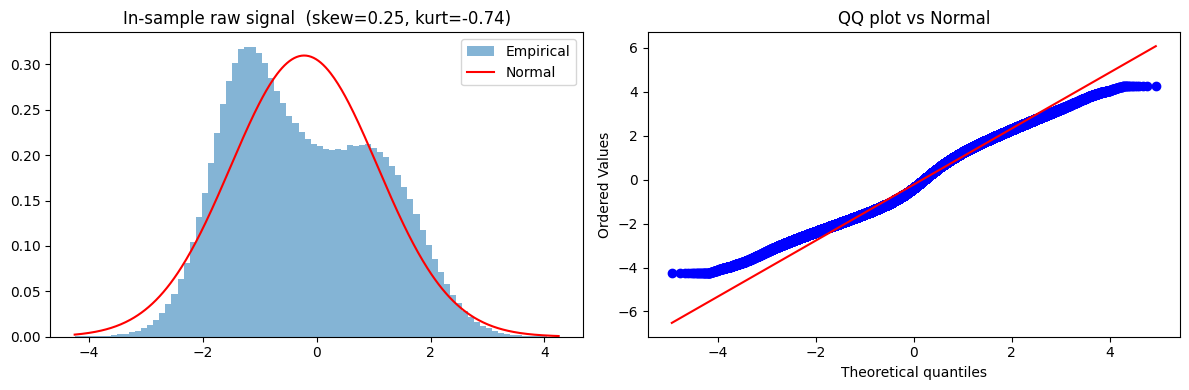

In [5]:
dist_plot(signal.loc[:IS_END].stack(), title='In-sample raw signal')


## Information Coefficient

Spearman rank correlation between today's signal and forward returns at multiple horizons. ICIR scales the mean IC by its time-series standard deviation; values around 0.05 in IC and 0.5 in ICIR are the conventional bar for a daily cross-sectional signal.


In [6]:
ic_is = ic(signal.loc[:IS_END], close.loc[:IS_END])
ic_is


,IC,ICIR
1,0.0112,0.0767
5,0.0188,0.1339
10,0.0204,0.1504
20,0.0207,0.1581


## Parameter Grid: IC Heatmap

Two-dimensional grid over (`lookback`, forward horizon). Each cell is the mean IC of the signal at that parameter and horizon. A signal whose performance is highly sensitive to a single point in the grid is more likely to be a fitting artefact than a real effect.


In [7]:
grid = [10, 20, 40, 60]
ic_results = {}
for p in grid:
    sig = mean_reversion(close, lookback=p)
    ic_results[p] = ic(sig.loc[:IS_END], close.loc[:IS_END])
ic_all = pd.concat(ic_results, names=['lookback'])
ic_all


IC   ICIR
lookback                 
10       1  0.0131 0.0915
         5  0.0192 0.1423
         10 0.0203 0.1552
         20 0.0194 0.1554
20       1  0.0112 0.0767
         5  0.0188 0.1339
         10 0.0204 0.1504
         20 0.0207 0.1581
40       1  0.0077 0.0506
         5  0.0138 0.0923
         10 0.0165 0.1157
         20 0.0195 0.1402
60       1  0.0054 0.0349
         5  0.0118 0.0760
         10 0.0163 0.1091
         20 0.0197 0.1331

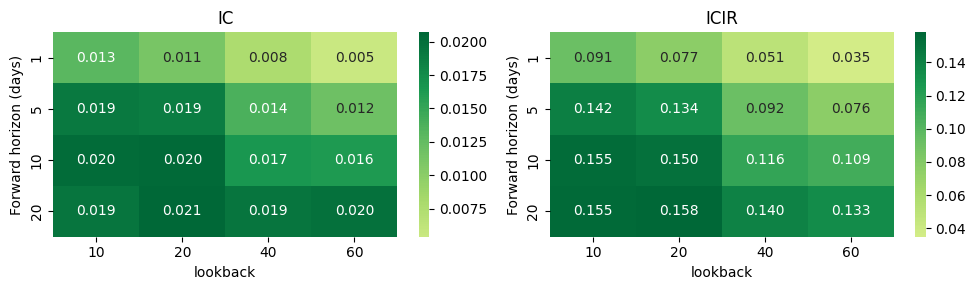

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i, col in enumerate(['IC', 'ICIR']):
    pivot = ic_all[col].unstack(level=0)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Forward horizon (days)')
    axes[i].set_xlabel('lookback')
plt.tight_layout()
plt.show()


## Parameter Selection by Backtest Sharpe

IC is a predictive-correlation metric and does not capture how the signal interacts with portfolio constraints, transaction costs, or covariance structure. The more rigorous parameter selection is to run the actual backtest at each grid point and rank by net Sharpe. We use rank-weighted portfolios at 5 bps cost as a tractable proxy for the optimized backtest.


In [9]:
sharpe_grid = {}
for p in grid:
    sig = mean_reversion(close, lookback=p)
    w = quick_weights(sig.loc[:IS_END], dollar_neutral=True)
    pnl = port_ret(w, returns.loc[:IS_END], tcost_bps=5)
    sr = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan
    sharpe_grid[p] = round(sr, 3)
pd.Series(sharpe_grid, name='Sharpe').rename_axis('lookback')


lookback
10   -0.3680
20    0.0580
40    0.1920
60    0.2540
Name: Sharpe, dtype: float64

Note that the parameter that maximises IC need not maximise Sharpe. When they disagree, trust the Sharpe ranking for parameter selection since it accounts for transaction costs, autocorrelation in the signal, and the cross-sectional correlation structure of returns.


## Rolling IC Stability

A signal that worked once and decayed is not the same as one that works persistently. The rolling 1-year IC tells us whether the predictive content survives across regimes.


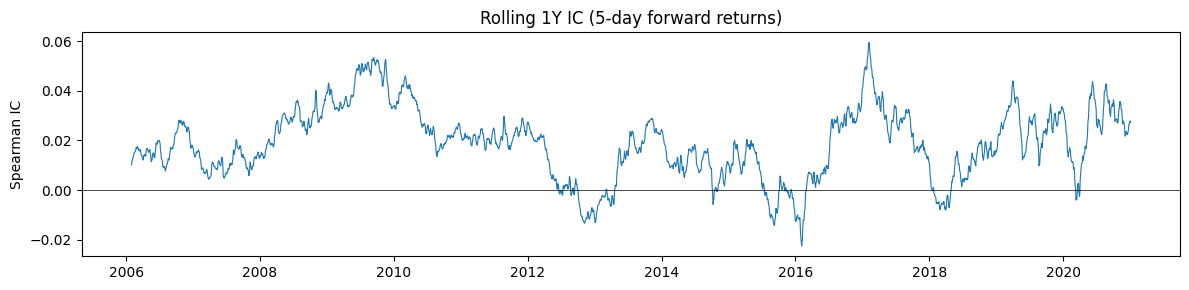

% of days with positive IC: 54.5%


In [10]:
fwd_5d = close.pct_change(5).shift(-5)
daily_ic = signal.loc[:IS_END].corrwith(fwd_5d.loc[:IS_END], axis=1, method='spearman')
rolling_ic = daily_ic.rolling(252).mean()
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rolling_ic, linewidth=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Rolling 1Y IC (5-day forward returns)')
ax.set_ylabel('Spearman IC')
plt.tight_layout()
plt.show()
print(f'% of days with positive IC: {(daily_ic > 0).mean():.1%}')


## Factor Neutralization

The raw signal is likely correlated with market beta: high-beta names move more, which can inflate signal strength in directions that simply express market exposure. We strip out the linear component explained by each stock's rolling SPY beta and re-evaluate.


In [11]:
betas = beta_to(returns, spy, lookback=252)
signal_neutral = neutralize(signal, betas)
ic(signal_neutral.loc[:IS_END], close.loc[:IS_END])


,IC,ICIR
1,0.0110,0.0921
5,0.0178,0.1550
10,0.0203,0.1800
20,0.0209,0.1930


If the IC survives neutralization, the signal carries information beyond market exposure. If it collapses, the original signal was largely a beta bet.


## In-Sample Backtest: Rank Weights

Dollar-neutral rank-weighted portfolio with no transaction costs. The cheapest possible expression of the signal, useful as a baseline before introducing the optimizer.


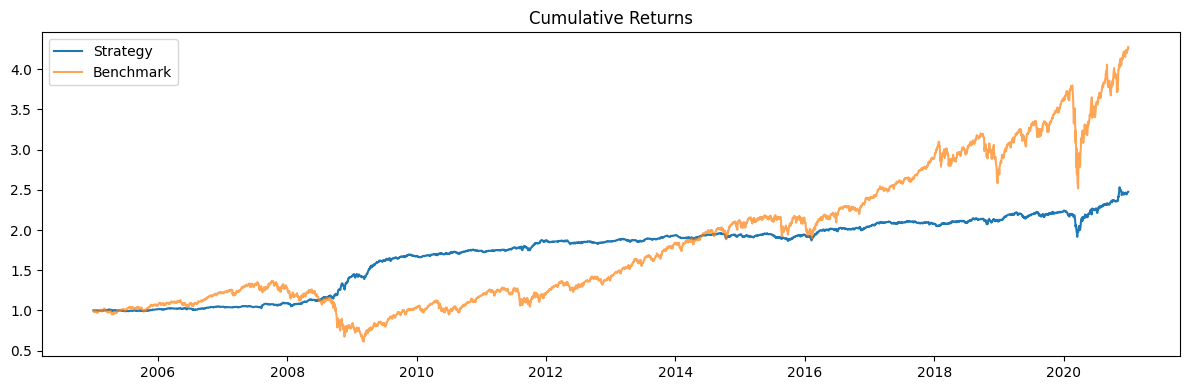

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,5.81%,5.31%,1.0960,4.3810,-14.61%,-0.97%,373 days,4.96%,3.8970,0.0780,43.71%


In [12]:
is_signal = signal.loc[:IS_END]
is_returns = returns.loc[:IS_END]
w_quick = quick_weights(is_signal, dollar_neutral=True)
pnl_quick = port_ret(w_quick, is_returns)
stats_quick = stats(pnl_quick, weights=w_quick, benchmark=spy.loc[:IS_END])
stats_quick


## Transaction Cost Sensitivity

Daily-rebalanced strategies are turnover-intensive. The Sharpe at non-zero costs is what matters in production.


In [13]:
tcost_grid = [0, 2, 5, 10, 20]
tcost_sharpes = {}
for tc in tcost_grid:
    pnl = port_ret(w_quick, is_returns, tcost_bps=tc)
    sr = pnl.mean() / pnl.std() * np.sqrt(252)
    tcost_sharpes[tc] = round(sr, 3)
pd.Series(tcost_sharpes, name='Sharpe').rename_axis('tcost (bps)')


tcost (bps)
0     1.0960
2     0.6810
5     0.0580
10   -0.9850
20   -3.0850
Name: Sharpe, dtype: float64

## In-Sample Backtest: Optimized Weights

Mean-variance optimizer with a 5 bps transaction-cost penalty and a 2% per-name position cap. The optimizer trades signal strength against covariance risk and rebalancing cost, producing weights that are not achievable from a one-shot ranking.


  solved 200/806


  solved 400/806


  solved 600/806


  solved 800/806


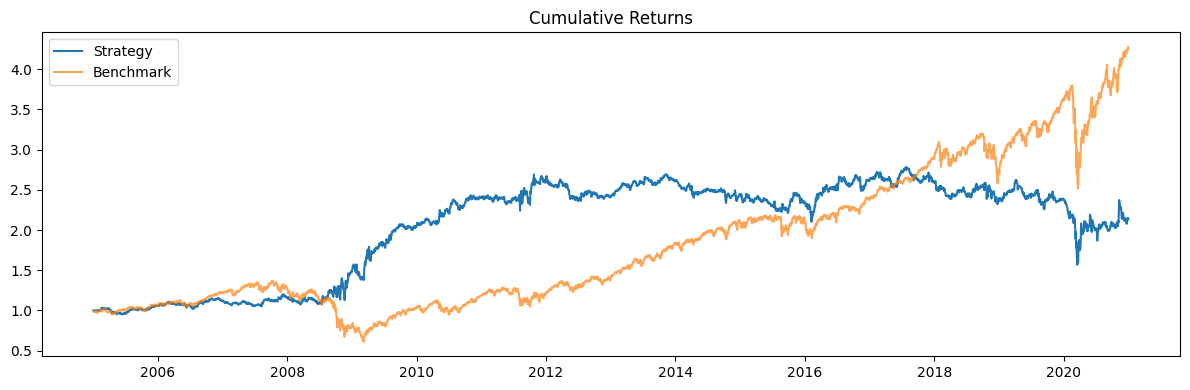

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,6.04%,15.92%,0.3790,1.5160,-43.76%,-7.09%,864 days,2.57%,0.6990,0.3150,59.53%


In [14]:
opt = Optimizer(is_signal, is_returns)
w_opt = opt.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True)
pnl_opt = port_ret(w_opt, is_returns, tcost_bps=5)
stats_opt = stats(pnl_opt, weights=w_opt, benchmark=spy.loc[:IS_END])
stats_opt


In [15]:
pd.concat([stats_quick.rename(index={'Strategy': 'Rank-weighted'}),
           stats_opt.rename(index={'Strategy': 'Optimized'})])


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Rank-weighted,5.81%,5.31%,1.0960,4.3810,-14.61%,-0.97%,373 days,4.96%,3.8970,0.0780,43.71%
Optimized,6.04%,15.92%,0.3790,1.5160,-43.76%,-7.09%,864 days,2.57%,0.6990,0.3150,59.53%


## Return Distribution and Tail Risk

Sharpe summarises the joint distribution but hides the tails. We plot the empirical return distribution against the Gaussian implied by the same mean and variance, then quantify tail risk via historical and parametric VaR / CVaR. The gap between the two estimates is itself informative: large gaps mean the Gaussian is a poor model for tail risk.


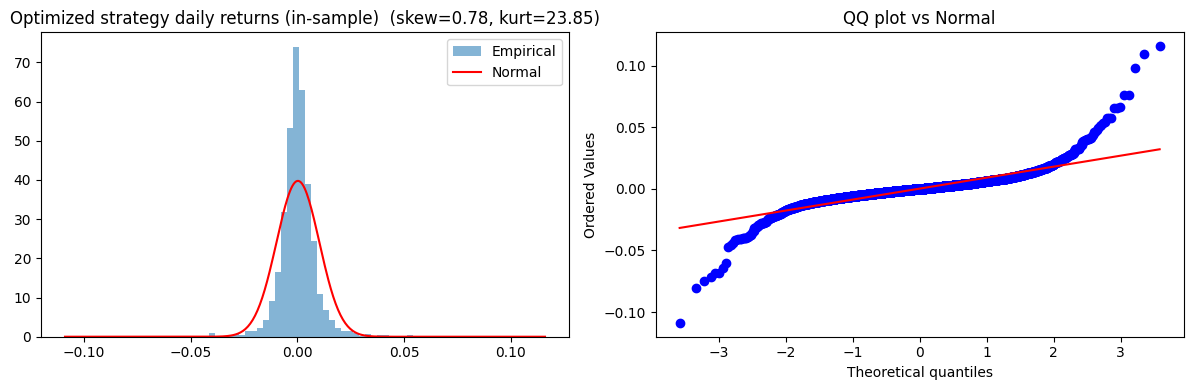

In [16]:
dist_plot(pnl_opt, title='Optimized strategy daily returns (in-sample)')


In [17]:
var_cvar(pnl_opt, alpha=0.05)


,VaR,CVaR
historical,-1.18%,-2.18%
parametric,-1.63%,-2.05%


In [18]:
var_cvar(pnl_opt, alpha=0.01)


,VaR,CVaR
historical,-2.74%,-4.31%
parametric,-2.31%,-2.65%


## Out-of-Sample Validation (2021 onward)

Everything above used data through end of 2020. The post-2020 panel is the genuine test: no parameter was chosen with reference to it.


In [19]:
oos_signal = signal.loc[IS_END:]
oos_returns = returns.loc[IS_END:]
ic(oos_signal, close.loc[IS_END:])


,IC,ICIR
1,0.0062,0.0323
5,0.0045,0.0268
10,0.0045,0.0277
20,0.0006,0.0040


  solved 200/262


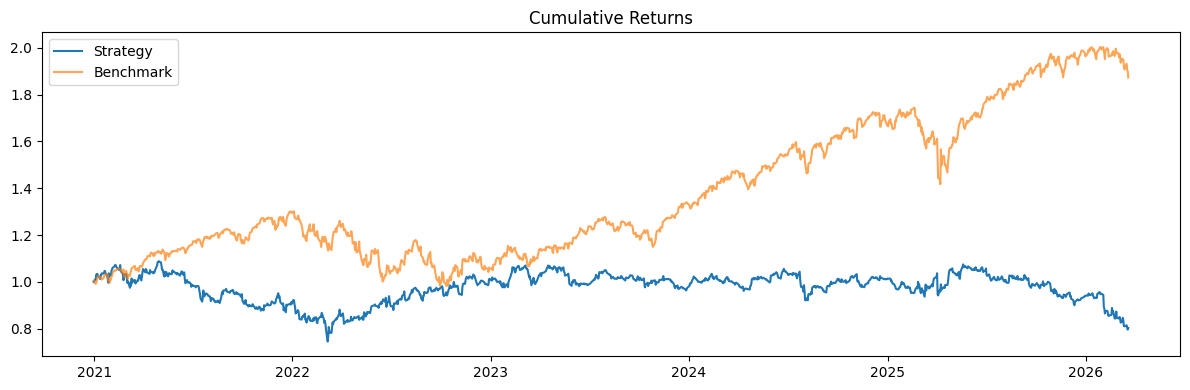

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,-2.68%,17.47%,-0.1530,-0.3490,-31.52%,-10.12%,1227 days,-6.19%,-0.8330,0.2600,61.99%


In [20]:
opt_oos = Optimizer(oos_signal, oos_returns)
w_oos = opt_oos.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True)
pnl_oos = port_ret(w_oos, oos_returns, tcost_bps=5)
stats_oos = stats(pnl_oos, weights=w_oos, benchmark=spy.loc[IS_END:])
stats_oos


In [21]:
pd.concat([stats_opt.rename(index={'Strategy': 'In-sample (2005-2020)'}),
           stats_oos.rename(index={'Strategy': 'Out-of-sample (2021+)'})])


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
In-sample (2005-2020),6.04%,15.92%,0.3790,1.5160,-43.76%,-7.09%,864 days,2.57%,0.6990,0.3150,59.53%
Out-of-sample (2021+),-2.68%,17.47%,-0.1530,-0.3490,-31.52%,-10.12%,1227 days,-6.19%,-0.8330,0.2600,61.99%


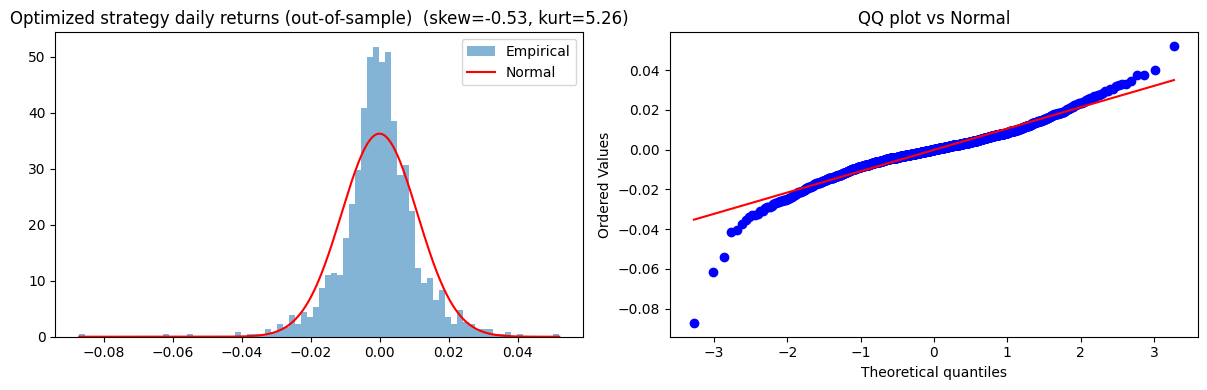

In [22]:
dist_plot(pnl_oos, title='Optimized strategy daily returns (out-of-sample)')


In [23]:
var_cvar(pnl_oos, alpha=0.05)


,VaR,CVaR
historical,-1.76%,-2.66%
parametric,-1.82%,-2.28%


## Annual Returns

Year-by-year breakdown highlights regime sensitivity that aggregate Sharpe figures hide.


In [24]:
full_signal = signal.loc['2006':]
full_returns = returns.loc['2006':]
w_full = quick_weights(full_signal, dollar_neutral=True)
pnl_full = port_ret(w_full, full_returns)
annual = pnl_full.groupby(pnl_full.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_spy = spy.loc['2006':].groupby(spy.loc['2006':].index.year).apply(lambda x: (1 + x).prod() - 1)
annual_df = pd.DataFrame({'Strategy': annual, 'SPY': annual_spy, 'Excess': annual - annual_spy})
annual_df.style.format('{:.2%}')


,Strategy,SPY,Excess
Date,,,
2006,2.73%,15.85%,-13.12%
2007,4.39%,5.15%,-0.76%
2008,30.59%,-36.80%,67.39%
2009,17.72%,26.35%,-8.63%
2010,3.96%,15.06%,-11.09%
2011,6.89%,1.90%,4.99%
2012,-0.30%,15.99%,-16.29%
2013,4.06%,32.31%,-28.25%
2014,0.55%,13.46%,-12.92%


## Save Weights

Persist optimised weights and signal panel so the portfolio capstone and the Monte Carlo notebook can consume them without recomputing.


In [25]:
w_opt.to_parquet('../data/weights_01_mean_reversion_is.parquet')
w_oos.to_parquet('../data/weights_01_mean_reversion_oos.parquet')
signal.to_parquet('../data/signal_01_mean_reversion.parquet')
